In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import t

from skewt_scipy.skewt import skewt 

In [2]:
def skewed_t_pdf(x, xi, omega, alpha, nu):
    """
    Azzalini & Capitanio skewed t-distribution PDF
    
    Parameters:
    xi: location parameter
    omega: scale parameter (> 0)
    alpha: skewness parameter
    nu: degrees of freedom (> 0)
    """
    # Standardize
    z = (x - xi) / omega
    
    # Student's t PDF
    t_pdf = t.pdf(z, df=nu)
    
    # Student's t CDF with modified argument
    t_cdf = t.cdf(alpha * z * np.sqrt((nu + 1) / (nu + z**2)), df=nu + 1)
    
    # Skewed t PDF
    pdf = (2 / omega) * t_pdf * t_cdf
    
    return pdf


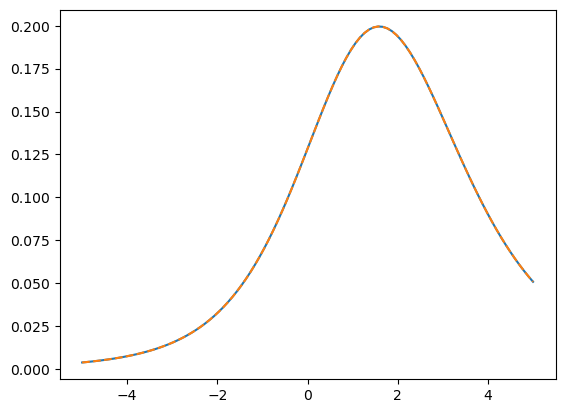

In [4]:
xi = 1.0
omega = 2.0
alpha = 0.5
nu = 4

xs = np.linspace(-5, 5, 100)

pdf1 = skewed_t_pdf(xs, xi, omega, alpha, nu)
pdf2 = skewt.pdf(xs, loc=xi, scale=omega, a=alpha, df=nu)

plt.plot(xs, pdf1)
plt.plot(xs, pdf2, '--')